# Homework 1 - data validation & cleaning (deadline 3. 11. 2024, 23:59)

In short, the main task is to clean The Metropolitan Museum of Art Open Access dataset.
  
> The instructions are not given in detail: It is up to you to come up with ideas on how to fulfill the particular tasks as best as possible!

However, we **strongly recommend and require** the following:
* Follow the assignment step by step. Number each step.
* Most steps contain the number of features that should be treated. You can preprocess more features. However, it does not mean the teacher will give you more points. Focus on quality, not quantity.
* Properly comment on all your steps. Use Markdown cells and visualizations. Comments are evaluated for 2 points of the total, together with the final presentation of the solution. However, it is not desirable to write novels! 
* This task is timewise and computationally intensive. Do not leave it to the last minute.
* Hand in a notebook that has already been run (i.e., do not delete outputs before handing in).

## What are you supposed to do:

  1. Download the dataset MetObjects.csv from the repository https://github.com/metmuseum/openaccess/.
  1. Check consistency (i.e., that the same things are represented in the same way) of at least **three features** where you expect problems (including the "Object Name" feature). You can propose how to clean the selected features. However, **do not apply cleaning** (in your interest) 🙂 _(1.5 points)_
  1. Select at least **two features** (i.e., one couple) where you expect integrity problems (describe your choice) and check the integrity of those features. By integrity, we mean correct logical relations between features (e.g., female names for females only). _(2 points)_
  1. Convert at least **five features** to a proper data type. Choose at least one numeric, one categorical (i.e., ordinal or nominal), and one datetime. _(1.5 points)_
  1. Find some outliers and describe your method. _(3 points, depends on creativity)_
  1. Detect missing data in at least **three features**, convert them to a proper representation (if they are already not), and impute missing values in at least **one feature** using some imputation method (i.e., imputation by mean or median is too trivial to obtain any points). _(2 + 3 points, depends on creativity)_
  1. Focus more precisely on cleaning the "Medium" feature. As if you were to use it in the KNN classification algorithm later. _(3 points)_
  1. Focus on the extraction of the physical dimensions of each item (width, depth, and height in centimeters) from the "Dimensions" feature. _(2 points)_
  
All your steps, your choices of methods, and the following code **must be commented on!** For text comments (discussion, etc., not code comments), use **Markdown cells**. Comments are evaluated for 2 points together with the final presentation of the solution. 

**If you do all this properly, you will obtain 20 points.**

## Comments

  * Please follow the technical instructions from https://courses.fit.cvut.cz/NI-PDD/homeworks/index.html.
  * Methods that are more complex and were not shown during the tutorials are considered more creative and should be described in detail.
  * English is not compulsory.

In [1]:
import re
import string
from unittest.mock import inplace

import numpy as np
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

dataset_path = 'MetObjects.txt'
rd_seed = 42

# 0. Dataset Exploration

## Columns Description

On [API pages](https://metmuseum.github.io/) we can find some information about the columns we have here.

In [2]:
df = pd.read_csv(dataset_path, low_memory=False)
df.head(10)

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
5,67.265.12,False,False,False,6,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/6,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
6,67.265.13,False,False,False,7,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/7,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Birds|Coins,http://vocab.getty.edu/page/aat/300266506|http...,https://www.wikidata.org/wiki/Q5113|https://ww...
7,67.265.14,False,False,False,8,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/8,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Eagles|Men|Profiles,http://vocab.getty.edu/page/aat/300250049|http...,https://www.wikidata.org/wiki/Q2092297|https:/...
8,67.265.15,False,False,False,9,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/9,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
9,1979.486.3,False,False,False,10,NaN,The American Wing,1979,Coin,Two-and-a-half-dollar Indian Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/10,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


Documented columns:

| Field                   | Type | Notes | Example(s) |
|-------------------------|-|-|-|
| Is Highlight            | boolean | When "true" indicates a popular and important artwork in the collection | Vincent van Gogh's "Wheat Field with Cypresses" |
| Is Timeline Work        | boolean | Whether the object is on the Timeline of Art History website | true |
| Is Public Domain        | boolean | When "true" indicates an artwork in the Public Domain | Vincent van Gogh's "Wheat Field with Cypresses" |
| Object ID               | int | Identifying number for each artwork (unique, can be used as key field) | 437133 |
| Gallery Number          | string | Gallery number, where available | "131" |
| Department              | string | Indicates The Met's curatorial department responsible for the artwork | "Egyptian Art" |
| Accession Year          | string | Year the artwork was acquired. | "1921" |
| Object Name             | string | Describes the physical type of the object | "Dress", "Painting", "Photograph", or "Vase" |
| Title                   | string | Title, identifying phrase, or name given to a work of art | "Wheat Field with Cypresses" |
| Culture                 | string | Information about the culture, or people from which an object was created | "Afghan", "British", "North African" |
| Period                  | string | Time or time period when an object was created | "Ming dynasty (1368-1644)", "Middle Bronze Age" |
| Dynasty                 | string | Dynasty (a succession of rulers of the same line or family) under which an object was created | "Kingdom of Benin", "Dynasty 12" |
| Reign                   | string | Reign of a monarch or ruler under which an object was created | "Amenhotep III", "Darius I", "Louis XVI" |
| Portfolio               | string | A set of works created as a group or published as a series. | "Birds of America", "The Hudson River Portfolio", "Speculum Romanae Magnificentiae" |
| Artist Role             | string | Role of the artist related to the type of artwork or object that was created | "Artist for Painting", "Designer for Dress" |
| Artist Prefix           | string | Describes the extent of creation or describes an attribution qualifier to the information given in the artistRole field | "In the Style of", "Possibly by", "Written in French by" |
| Artist Display Name     | string | Artist name in the correct order for display | "Vincent van Gogh" |
| Artist Display Bio      | string | Nationality and life dates of an artist, also includes birth and death city when known. | "Dutch, Zundert 1853–1890 Auvers-sur-Oise" |
| Artist Suffix           | string | Used to record complex information that qualifies the role of a constituent, e.g. extent of participation by the Constituent (verso only, and followers) | "verso only" |
| Artist Alpha Sort       | string | Used to sort artist names alphabetically. Last Name, First Name, Middle Name, Suffix, and Honorific fields, in that order. | "Gogh, Vincent van" |
| Artist Nationality      | string | National, geopolitical, cultural, or ethnic origins or affiliation of the creator or institution that made the artwork | "Spanish"; "Dutch"; "French, born Romania" |
| Artist Begin Date       | string | Year the artist was born | "1840" |
| Artist End Date         | string | Year the artist died | "1926" |
| Artist Gender           | string | Gender of the artist (currently contains female designations only) | "female" |
| Artist ULAN_URL         | string | ULAN URL for the artist | "https://vocab.getty.edu/page/ulan/500003169" |
| Artist Wikidata_URL     | string | Wikidata URL for the artist | "https://www.wikidata.org/wiki/Q694774" |
| Object Date             | string | Year, a span of years, or a phrase that describes the specific or approximate date when an artwork was designed or created | "1865–67", "19th century", "ca. 1796" |
| Object Begin Date       | int | Machine readable date indicating the year the artwork was started to be created | 1867, 1100, -900 |
| Object End Date         | int | Machine readable date indicating the year the artwork was completed (may be the same year or different year than the objectBeginDate) | 1888, 1100, -850 |
| Medium                  | string | Refers to the materials that were used to create the artwork | "Oil on canvas", "Watercolor", "Gold" |
| Dimensions              | string | Size of the artwork or object | "16 x 20 in. (40.6 x 50.8 cm)" |
| Credit Line             | string | Text acknowledging the source or origin of the artwork and the year the object was acquired by the museum. | "Robert Lehman Collection, 1975" |
| Geography Type          | string | Qualifying information that describes the relationship of the place catalogued in the geography fields to the object that is being catalogued | "Made in", "From", "Attributed to" |
| City                    | string | City where the artwork was created | "New York", "Paris", "Tokyo" |
| State                   | string | State or province where the artwork was created, may sometimes overlap with County | "Alamance", "Derbyshire", "Brooklyn" |
| County                  | string | County where the artwork was created, may sometimes overlap with State | "Orange County", "Staffordshire", "Brooklyn" |
| Country                 | string | Country where the artwork was created or found | "China", "France", "India" |
| Region                  | string | Geographic location more specific than country, but more specific than subregion, where the artwork was created or found (frequently null) | "Bohemia", "Midwest", "Southern" |
| Subregion               | string | Geographic location more specific than Region, but less specific than Locale, where the artwork was created or found (frequently null) | "Malqata", "Deir el-Bahri", "Valley of the Kings" |
| Locale                  | string | Geographic location more specific than subregion, but more specific than locus, where the artwork was found (frequently null) | "Tomb of Perneb", "Temple of Hatshepsut", "Palace of Ramesses II" |
| Locus                   | string | Geographic location that is less specific than locale, but more specific than excavation, where the artwork was found (frequently null) | "1st chamber W. wall"; "Burial C 2, In coffin"; "Pit 477" |
| Excavation              | string | The name of an excavation. The excavation field usually includes dates of excavation. | "MMA excavations, 1923–24"; "Khashaba excavations, 1910–11"; "Carnarvon excavations, 1912" |
| River                   | string | River is a natural watercourse, usually freshwater, flowing toward an ocean, a lake, a sea or another river related to the origins of an artwork (frequently null) | "Mississippi River", "Nile River", "River Thames" |
| Classification          | string | General term describing the artwork type. | "Basketry", "Ceramics", "Paintings" |
| Rights And Reproduction | string | Credit line for artworks still under copyright. | "© 2018 Estate of Pablo Picasso / Artists Rights Society (ARS), New York" |
| Link Resource           | string | URL to object's page on metmuseum.org | "https://www.metmuseum.org/art/collection/search/547802" |
| Object Wikidata_URL     | string | Wikidata URL for the object | "https://www.wikidata.org/wiki/Q432253" |
| Metadata Date           | datetime | Date metadata was last updated | 2018-10-17T10:24:43.197Z |
| Repository              | string |  | "Metropolitan Museum of Art, New York, NY" |
| Tags                    | array | An array of subject keyword tags associated with the object and their respective AAT URL | [{"term": "Abstraction","AAT_URL": "http://vocab.getty.edu/page/aat/300056508","Wikidata_URL": "https://www.wikidata.org/wiki/Q162150"}] |




**Constituend ID** meaning can be deduced from the **constituents** attribute in API documentation.

| Field                   | Type | Notes | Example(s) |
|-------------------------|-|-|-|
| constituents            | array | An array containing the constituents associated with an object, with the constituent's role, name, ULAN URL, Wikidata URL, and gender, when available (currently contains female designations only). | [{"constituentID": 161708,"role": "Artist","name": "Louise Bourgeois","constituentULAN_URL": "http://vocab.getty.edu/page/ulan/500057350","constituentWikidata_URL": "https://www.wikidata.org/wiki/Q159409","gender": "Female"}] |

# 1. Consistency

Consistency is about to check if same things are represented in the same way. Thus, representation is consistent across all the dataset.

There are different ways to examine consistency, depending on the feature we examine.

We will define helper functions here to check consistency of features that will follow.

In [3]:
def unique_difference(transformation, df_orig):
    """
    Function to find all unique domain values of transformation function.
    
    It is used to find all the original values, that has same representation after applying transformation.
    For example, if transformation is lowercase, then 'Coin' and 'coin' will transform to 'coin'. 
    This function helps to visualize such occurrences, so we can check consistency, i.e. if all strigns are lowercased.  
    :param transformation: function which transform values.
    :param df_orig: dataframe to examine.
    :return: key-value pairs, where key is the range, and value is domain of transformation function.
    """
    before_nuniques = df_orig.nunique()
    df_transformed = df_orig.apply(func=transformation)
    after_nuniques = df_transformed.nunique()
    diff = before_nuniques - after_nuniques

    # print some statistics
    print(f'Number of unique values before {transformation.__name__}: {before_nuniques}')
    print(f'Number of unique values after {transformation.__name__}: {after_nuniques}')
    print(f'Difference: {diff}')
    print(
        f'Ratio of values with different cases to all uniques before {transformation.__name__}: {diff / before_nuniques:.2f}')

    orig_uniques = df_orig.unique()

    transformation_mappings = dict()
    for original_value in orig_uniques:
        transformed = transformation(original_value)
        if transformed not in transformation_mappings:
            transformation_mappings[transformed] = set()
        transformation_mappings[transformed].add(original_value)

    # filter from key-value pairs, where only one unique value from domain is mapped to one range value.
    filtered_from_singletons = {transformed: originals for transformed, originals in transformation_mappings.items() if
                                len(originals) > 1}
    return filtered_from_singletons


def display_top_n_dict(dictionary, n: int = 5):
    """Helper function to display unique differences."""
    top_n_examples_list = [item for idx, item in enumerate(dictionary.items()) if idx < n]
    print(f'Top {n} examples:')
    display(top_n_examples_list)

Here we define some transformation function that we will use:

In [4]:
def lowercase(string: str | None) -> str | None:
    return string.lower()


def whitespaces_reduction(string: str | None) -> str | None:
    return re.sub(r'\s+', ' ', string.strip())


def special_characters_reduction(string: str, pattern=r'[^\w\s]') -> str:
    return re.sub(pattern, '', string)

## Object Name

| Field                   | Type | Notes | Example(s) |
|-------------------------|-|-|-|
| Object Name             | string | Describes the physical type of the object | "Dress", "Painting", "Photograph", or "Vase" |

We will examine following inconsistencies:
- case consistency - lowercase and uppercase
- leading, intermediate, trailing whitespaces
- special characters and punctuation

In [11]:
ser_obj_nm = df['Object Name']

In [87]:
def introduce_data(data: pd.DataFrame | pd.Series, column=None):
    if column:
        series = data[column]
    else:
        series = data
    display(series.describe())
    display(series.info())
    print(f'Number of NaN values: {series.isna().sum()} ({100 * series.isna().sum() / len(series):.2f}%)')


introduce_data(ser_obj_nm)

count     482690
unique     28631
top        Print
freq      102986
Name: Object Name, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Object Name
Non-Null Count   Dtype 
--------------   ----- 
482690 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 2266 (0.47%)


In [13]:
# to apply transformation functions we need to get rid of NaN values
ser_obj_nm_dropna = ser_obj_nm.dropna()

Case consistency check:

In [15]:
display_top_n_dict(unique_difference(lowercase, ser_obj_nm_dropna), 5)

Number of unique values before lowercase: 28631
Number of unique values after lowercase: 27760
Difference: 871
Ratio of values with different cases to all uniques before lowercase: 0.03
Top 5 examples:


[('coin', {'Coin', 'coin'}),
 ('vase', {'Vase', 'vase'}),
 ('side chair', {'Side Chair', 'Side chair'}),
 ('figure', {'FIgure', 'Figure'}),
 ('statuette', {'Statuette', 'statuette'})]

3% of unique values differs only in case from the rest.


Whitespaces check:

In [16]:
display_top_n_dict(unique_difference(whitespaces_reduction, ser_obj_nm_dropna))

Number of unique values before whitespaces_reduction: 28631
Number of unique values after whitespaces_reduction: 28293
Difference: 338
Ratio of values with different cases to all uniques before whitespaces_reduction: 0.01
Top 5 examples:


[('Bust', {'Bust', 'Bust '}),
 ('Vase', {'Vase', 'Vase\r\n', 'Vase ', 'Vase \r\n'}),
 ('Figure', {'Figure', 'Figure\r\n', 'Figure ', 'Figure \r\n'}),
 ('Andiron', {'Andiron', 'Andiron '}),
 ('Statuette', {'Statuette', 'Statuette '})]

Only 1% of values have inconsistency with whitespaces.

Special characters check:


In [17]:
print(f'Considered special characters: {string.punctuation}')

Considered special characters: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [18]:
display_top_n_dict(unique_difference(special_characters_reduction, ser_obj_nm_dropna), 5)

Number of unique values before special_characters_reduction: 28631
Number of unique values after special_characters_reduction: 28311
Difference: 320
Ratio of values with different cases to all uniques before special_characters_reduction: 0.01
Top 5 examples:


[('Teapot', {'"Tea-pot"', 'Teapot'}),
 ('Dish', {'Dish', 'Dish(?)'}),
 ('Curtain tieback', {'Curtain tie-back', 'Curtain tieback'}),
 ('Plate', {'Plate', 'Plate?'}),
 ('Gateleg table', {'Gate-leg table', 'Gateleg table'})]

Only 1% of unique values have special characters inconsistency.

Another inconsistency is with using '?' in different formats, like with or without parenthesis. To consider examples like 'Plate' and 'Plate?' as inconsistent is a good question, because the question mark represents uncertainty, which may be important information. 

Also, from example we see, that dashes '-' are also used inconsistently.

Let's apply all all the transformations and see the overall percentage of inconsistency among unique values:

In [19]:
display_top_n_dict(
    unique_difference(lambda x: special_characters_reduction(whitespaces_reduction(lowercase(x))), ser_obj_nm_dropna),
    5)

Number of unique values before <lambda>: 28631
Number of unique values after <lambda>: 27110
Difference: 1521
Ratio of values with different cases to all uniques before <lambda>: 0.05
Top 5 examples:


[('coin', {'Coin', 'coin'}),
 ('bust', {'Bust', 'Bust '}),
 ('vase', {'Vase', 'Vase\r\n', 'Vase ', 'Vase \r\n', 'vase'}),
 ('side chair', {'Side Chair', 'Side chair', 'Side chair '}),
 ('figure',
  {'FIgure', 'FIgure\r\n', 'Figure', 'Figure\r\n', 'Figure ', 'Figure \r\n'})]

5% of unique values are inconsistent using all of our 3 transformations. Of course, there may be other inconsistencies:
- misspells.
- different forms of a word, i.e. singular vs plural forms.

But those 5% are among unique values. Let's see how many values will be transformed to more consistent representation

In [74]:
df_obj_nm = pd.DataFrame(ser_obj_nm_dropna)
df_obj_nm['Object Name Lowercased'] = ser_obj_nm_dropna.apply(lambda x: lowercase(x))
df_obj_nm['Object Name W-S Reduction'] = ser_obj_nm_dropna.apply(
    lambda x: special_characters_reduction(whitespaces_reduction(x)))
df_obj_nm['Object Name Transformed'] = ser_obj_nm_dropna.apply(
    lambda x: special_characters_reduction(whitespaces_reduction(lowercase(x))))
for column, transformation in {'Object Name Lowercased': 'Lowercasing',
                               'Object Name W-S Reduction': 'Whitespace-Special Characters Reduction',
                               'Object Name Transformed': 'Lowercasing & Whitespace-Special Characters Reduction'}.items():
    df_diff = df_obj_nm[df_obj_nm['Object Name'] != df_obj_nm[column]]
    print(f'Transformation: {transformation}')
    print(f'Number of transformed (changed) values: {len(df_diff)}')
    print(f'{100 * len(df_diff) / len(df_obj_nm):.1f}% of values were changed.' + '\n')

Transformation: Lowercasing
Number of transformed (changed) values: 481117
99.7% of values were changed.

Transformation: Whitespace-Special Characters Reduction
Number of transformed (changed) values: 68495
14.2% of values were changed.

Transformation: Lowercasing & Whitespace-Special Characters Reduction
Number of transformed (changed) values: 481647
99.8% of values were changed.



We see how many values our transformations affected.

Now, let's examine top short and long values to find there some inconsistencies:

In [22]:
df_obj_nm = pd.DataFrame(ser_obj_nm_dropna)
df_obj_nm['Object Name Length'] = ser_obj_nm_dropna.apply(len)
df_obj_nm.drop_duplicates(subset='Object Name', keep='first', inplace=True)
df_obj_nm.nlargest(5, 'Object Name Length')

,Object Name,Object Name Length
20103,Double-barreled flintlock shotgun with exchang...,80
20388,Nineteen ornamental fittings from a horse harn...,80
25170,Ammunition belt (Kamr) Object Cards. S. martz...,80
25748,Blade and for a hatchet (Nata) and mounting fo...,80
29500,"Set of Pommel (Fuchigashira), Sword grip ornam...",80


In [23]:
df_obj_nm.nsmallest(5, 'Object Name Length')

,Object Name,Object Name Length
20273,Ax,2
147303,As,2
335145,Ūd,2
335195,Po,2
335197,Lo,2


Seemingly there is no inconsistencies - but let's check all unique object names with length of 2 and 3:

In [24]:
print(f'Object names with the length of 2: {list(df_obj_nm[df_obj_nm["Object Name Length"] == 2]["Object Name"])}')
print(f'Object names with the length of 3: {list(df_obj_nm[df_obj_nm["Object Name Length"] == 3]["Object Name"])}')

Object names with the length of 2: ['Ax', 'As', 'Ūd', 'Po', 'Lo', 'Bo', 'Gu', 'Ty', 'So', 'Em', 'Se', 'Yu']
Object names with the length of 3: ['Mug', 'Keg', 'Cup', 'Box', 'Jar', 'Cap', 'Pin', 'Urn', 'Jug', 'Die', 'Fan', 'Toy', 'Key', 'Lid', 'Map', 'Tyg', 'Pan', 'Pot', 'Rug', 'Hat', 'Ale', 'Bit', 'Bow', 'Axe', 'Saw', 'Gun', 'Mat', 'Qin', 'Dog', 'Bar', 'Obi', 'Cat', 'Bag', 'Tub', 'Tab', 'Fob', 'Boa', 'Aba', 'Kit', 'Wig', 'Bib', 'Fez', 'Alb', 'Pax', 'Pyx', 'Pen', 'Bed', 'Awl', 'Tie', 'Wax', 'Rod', 'Peg', 'Arm', 'Oon', 'Aes', 'Oar', 'Net', 'Rim', 'Top', 'jar', 'Gem', 'Rib', 'Bes', 'Kei', 'Sho', 'Fue', 'Hnè', 'Ozi', 'Koy', 'Tar', 'Saz', 'Zil', 'Baz', 'Nāy', 'Nay', 'Ney', 'Coc', 'Mai', 'Aje', 'Mam', 'Tār', 'Oko', 'Daf', 'Òzi', 'Gyo', 'Shō', 'Hun', 'Udu', 'Xun', 'Kin', 'Kou', 'Sut', 'Tro', 'Shu', 'Hoe', 'cat', 'Toe', 'Waj', 'Nai']


Everything looks valid, if we assume that some of the names may be from different languages.
Checking typos may be not a good idea, because we work with different languages, so it is possible that we can 'fix' correct word from other language.

Al last consistency check we will perform frequency analysis, which may help us to find:
- unexpected values (values that appear too frequently or vice versa)
- outliers
- duplicated or missing data (for example '??' instead of NaN)
- biases in data

In [50]:
ser_obj_nm_vc = ser_obj_nm.value_counts()
print('Top frequent elements:')
display(ser_obj_nm_vc.head(10))
print('Least frequent elements:')
display(ser_obj_nm_vc.tail(10))

Top frequent elements:


Object Name
Print             102986
Photograph         29451
Drawing            26018
Book               13397
Kylix fragment      8926
Piece               8621
Fragment            7213
Painting            6014
Negative            5928
Bowl                3633
Name: count, dtype: int64

Least frequent elements:


Object Name
Lekaina                                    1
Plate, Genucilia                           1
Two Panathenaic prize amphora fragments    1
Kantharos or rhyton                        1
Kylix fragments (26)                       1
Oinochoe in the form of a head of a man    1
Diskos                                     1
Neck-amphora, Tyrrhenian, fragmentary      1
Relief fragments, 12                       1
etching                                    1
Name: count, dtype: int64

- 'Print' is the most frequent item, but in this context it is OK.

Overall, there are no inconsistencies. 

**Overall cleaning suggestions:**

To clean Object Name column we can apply our transformation, and figure out other similar transformations, like spellchecking, to make data even more consistent.

## Accession Year

In [88]:
ser_acsn_yr = df['AccessionYear']
introduce_data(ser_acsn_yr)

count     481094
unique       180
top         1963
freq       41980
Name: AccessionYear, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: AccessionYear
Non-Null Count   Dtype 
--------------   ----- 
481094 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 3862 (0.80%)


There are only 180 unique values, we can look at them manually:

In [54]:
ser_acsn_yr.unique()

array(['1979', '1980', '1967', '1916', '1909', '1964', '1970', '1904',
       '1976', '1938', '1918', '1946', '1960', '1910', '1922', '1923',
       '1930', '1934', '1936', '1937', '1939', '1941', '1947', '1948',
       '1949', '1971', '1984', '1989', '1985', '1952', '1968', '1919',
       nan, '1978', '1972', '1924', '1983', '1950', '1925', '1926',
       '1931', '1932', '1951', '1953', '2006', '1969', '1975', '1981',
       '1986', '1959', '1944', '1982', '1945', '1888', '1911', '1957',
       '1943', '1935', '1917', '1973', '1940', '1913', '1962', '1914',
       '1966', '1954', '1920', '1933', '2014', '1928', '1901', '1958',
       '1965', '1883', '1902', '1987', '1974', '1977', '1915', '1942',
       '1912', '1927', '1896', '1892', '1877', '1906', '1955', '1961',
       '1994', '1907', '1929', '2018', '1921', '1908', '1963', '2010',
       '2000', '1988', '2021', '1956', '2012', '2013', '2002', '1999',
       '1894', '1897', '1993', '1893', '1992', '1996', '1898', '1899',
       '1

We see there striking inconsistency in date format: 
- some of them are in more complete format, like '1968-12-12'.
- and others are just year, like '1961'.

Let's examine how many entires are ther with complete datetime:

In [81]:
print('Number of entries with complete datetime: {}'.format(ser_acsn_yr.str.match(r'\d{4}-\d{2}-\d{2}').sum()))

Number of entries with complete datetime: 40



To clean this, there are two options:
- because there are only 40 entries (by 4 magnitudes less that total number of rows), we can just delete them.
- if we need to save this data, we can save complete dates in a new column **Accession Date**, and in **Accession Year** substitute dates with years.

Option to convert years to dates is not suitable, because by conversion, every year will get some month and some day. But we don't know month and day the object actually was accessed, we just make up some data out of air, which may lead to problems later.

## Gallery Number

In [89]:
ser_gal_num = df['Gallery Number']
introduce_data(ser_gal_num)

count     49541
unique      379
top         774
freq       7547
Name: Gallery Number, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Gallery Number
Non-Null Count  Dtype 
--------------  ----- 
49541 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 435415 (89.78%)


- 89.78% of values are missing.
- there are only 378 unique values.
- type is object, implying that not all of the types are numerical.

Let's look at the data:

In [96]:
ser_gal_num.unique()[:80]

array([nan, '774', '706', '724', '741', '728', '719', '718', '729', '712',
       '516', '737', '738', '701', '734', '708', '722', '713', '730',
       '752', '736', '714', '740', '743', '725', '739', '745', '700',
       '704', '750', '512', '751', '717', '749', '733', '773', '710',
       '744', '726', '705', '732', '731', '723', '715', '508', '510',
       '747', '756', '720', '721', '766', '761', '762', '754', '372',
       '554', '707', '764', '768', '771', '760', '758', '759', '763',
       '681', '824', '769', '748', '753', '772', '755', 'in Great Hall',
       '767', '770', '765', '703', '809', '735', '727', '599'],
      dtype=object)

Some of the values are represented not as numbers, but as name of the gallery. Let's explore proportions of numbers, names and NaNs:

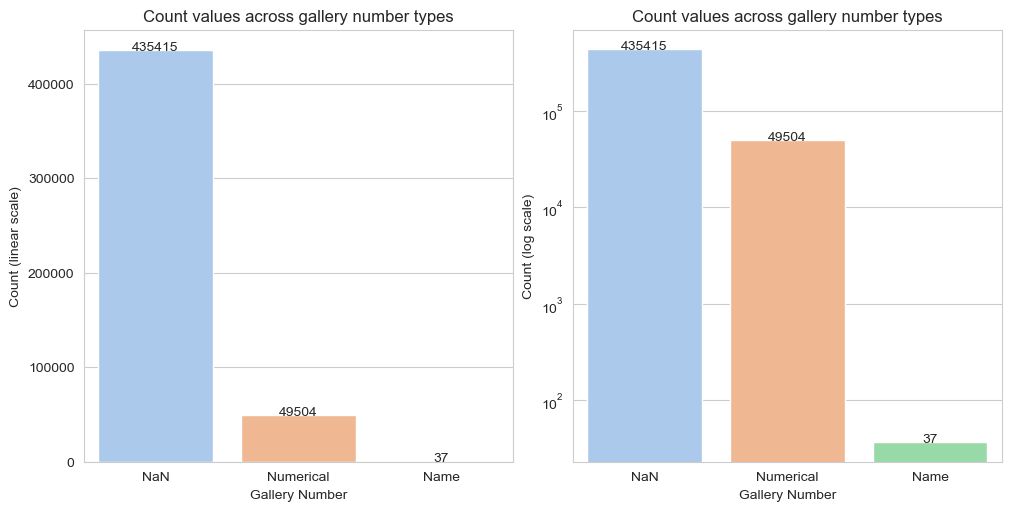

In [131]:
def categorize_gal_number(value):
    try:
        int(value)
        return 'Numerical'
    except ValueError:
        if pd.isna(value):
            return 'NaN'
        else:
            return 'Name'


ser_gal_num_categories_vc = ser_gal_num.apply(categorize_gal_number).value_counts()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), constrained_layout=True)

for ax, y_scale in zip(axes, ['linear', 'log']):
    sns.barplot(x=ser_gal_num_categories_vc.index, y=ser_gal_num_categories_vc.values,
                hue=ser_gal_num_categories_vc.index, palette='pastel', ax=ax)
    ax.set_title('Count values across gallery number types')
    ax.set_xlabel('Gallery Number')
    ax.set_ylabel('Count ({} scale)'.format(y_scale))
    ax.set_yscale(y_scale)

    for patch in ax.patches:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width() / 2, height, s=int(height), ha='center')

plt.show()

There are only 37 gallery name values. Let's also look at them:

In [148]:
ser_gal_num_no_nans = ser_gal_num.dropna()
unique_gal_names = list(ser_gal_num_no_nans[ser_gal_num_no_nans.str.match(r'[a-zA-Z]+')].unique())
print('Unique gallery names: {}'.format(unique_gal_names))

Unique gallery names: ['in Great Hall', 'Petrie Ct. Café', 'on Fifth Avenue', 'Watson Library']


There are only 4 unique values for gallery names.

**Conclusion:**
- certainly we see here inconsistency in gallery number representation. It should be a number, not string name.

**How to clean it:**
- because there are only 37 such rows, we can just drop them.
- we can convert this column to category type, where each value will have underlying category integer value (there are only 378 unique values, which isn't much)
- we can find on internet or ask the data provider about what numbers have those galleries, if the have any.
- think up own numbers, associate them with name and save associations into a dictionary, and replace strings names with numbers.

In our case the best solution would be change type to category.

# 2. Integrity Check

Integrity checks - basically stronger consistency checks, where we additionally check logic of the data given the context.
For example, if year values lie in certain range, given the context of the data. In our case, year cannot be in the future, and this check is an example of inegrity check, because logically the year cannot be in the future.
 

 ## Artist Begin Date & Artist End Date

We will check integrity between Artist Begin Date and Artist End Date. We know, that end year should be later than begin date. This is what we will check.

### Splitting Dataset into Objects and Artists

If we look at artists columns we will see, that they are concatenated lists, joined together by '|' (or in some cases without - we look at you, **Constituend ID**)

i.e. object 444:

In [3]:
artist_columns = ['Constituent ID', 'Artist Role', 'Artist Prefix', 'Artist Display Name', 'Artist Display Bio',
                  'Artist Suffix',
                  'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date', 'Artist End Date', 'Artist Gender',
                  'Artist ULAN URL', 'Artist Wikidata URL']

df[df['Object ID'] == 444][artist_columns]

,Constituent ID,Artist Role,Artist Prefix,Artist Display Name,Artist Display Bio,Artist Suffix,Artist Alpha Sort,Artist Nationality,Artist Begin Date,Artist End Date,Artist Gender,Artist ULAN URL,Artist Wikidata URL
387,1192174616222311149447,Maker|Maker|Decorator|Decorator|Decorator,Possibly by|Cornice attributed to|Painting att...,Thomas Seymour|John Doggett|John Ritto Pennima...,"1771–1848|1780–1857|American, Milford, Massach...",| | | |,"Seymour, Thomas|Doggett, John|Penniman, John R...",American|American|American|American|American,1771 |1780 |1782 |1757 |17...,1848 |1857 |1841 |1811 |18...,||||,http://vocab.getty.edu/page/ulan/500023428|htt...,https://www.wikidata.org/wiki/Q61764333|https:...


The biggest problem here is the **Constituent ID**, because IDs of artist are concatenated there without any delimiter (to overcome this problem, we need to find rows where there is only one artist, remember his ID, make a table from that, and iteratively deduce ID's of other artists by removing known IDs from the joined IDs). We will do nothing with that, just copy Constituent ID and if there is only one artist, we will mark it as his/her own ID in separete column (Artist ID), as well as order of that artist in the list (Constituent ID List Order).
 

In [58]:
# Object ID has no missing values and no duplicates, we will use it to bind tables
df_artists = pd.DataFrame(df['Object ID'])

# first, split entries by '|', assign orders, and create Artist ID column
for column in artist_columns:
    if column == 'Constituent ID':  # this column cannot be splitted
        df_artists[column] = df[column]
        continue
    artists_df_column_name = column.replace('Artist ', '').strip()
    df_artists[artists_df_column_name] = df[column].str.split('|')

df_artists['Constituents Number'] = df_artists['Display Name'].apply(
    lambda x: len(x) if isinstance(x, list) else np.nan
).astype(pd.Int64Dtype())

df_artists['Constituent Order'] = df_artists['Constituents Number'].apply(
    lambda x: np.nan if pd.isna(x) else list(range(int(x))))

df_artists['Artist ID'] = df_artists.apply(
    lambda row: [row['Constituent ID']] if isinstance(row['Constituent Order'], list) and len(
        row['Constituent Order']) == 1 else np.nan, axis=1)

df_artists.head(5)

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
0,1,16429,[Maker],[ ],[James Barton Longacre],"[American, Delaware County, Pennsylvania 1794–...",[ ],"[Longacre, James Barton]",[American],[1794 ],[1869 ],NaN,[http://vocab.getty.edu/page/ulan/500011409],[https://www.wikidata.org/wiki/Q3806459],1,[0],[16429]
1,2,107,[Maker],[ ],[Christian Gobrecht],[1785–1844],[ ],"[Gobrecht, Christian]",[American],[1785 ],[1844 ],NaN,[http://vocab.getty.edu/page/ulan/500077295],[https://www.wikidata.org/wiki/Q5109648],1,[0],[107]
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN


In [66]:
columns_to_explode = [column_name.replace('Artist ', '').strip() for column_name in artist_columns] + ['Artist ID',
                                                                                                       'Constituent Order']
columns_to_explode.remove('Constituent ID')

In [68]:
def nans_to_list(row: pd.DataFrame) -> pd.DataFrame:
    constituents_number = row['Constituents Number']
    if pd.isna(constituents_number):
        return row
    for column in columns_to_explode:
        if isinstance(row[column], list) or not pd.isna(row[column]):
            continue
        row[column] = [np.nan] * constituents_number
    return row

df_artists = df_artists.apply(nans_to_list, axis=1)

In [69]:
df_artists

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
0,1,16429,[Maker],[ ],[James Barton Longacre],"[American, Delaware County, Pennsylvania 1794–...",[ ],"[Longacre, James Barton]",[American],[1794 ],[1869 ],[nan],[http://vocab.getty.edu/page/ulan/500011409],[https://www.wikidata.org/wiki/Q3806459],1,[0],[16429]
1,2,107,[Maker],[ ],[Christian Gobrecht],[1785–1844],[ ],"[Gobrecht, Christian]",[American],[1785 ],[1844 ],[nan],[http://vocab.getty.edu/page/ulan/500077295],[https://www.wikidata.org/wiki/Q5109648],1,[0],[107]
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484951,900605,22488,[Artist],[ ],[Douglas Gorsline],"[American, Rochester, New York 1913–1985 Dijon...",[ ],"[Gorsline, Douglas]",[American],[1913 ],[1985 ],[nan],[nan],[nan],1,[0],[22488]
484952,900606,22488,[Artist],[ ],[Douglas Gorsline],"[American, Rochester, New York 1913–1985 Dijon...",[ ],"[Gorsline, Douglas]",[American],[1913 ],[1985 ],[nan],[nan],[nan],1,[0],[22488]
484953,900633,9738,[Artist],[ ],[Edmond Mario Granville],"[American, Chicago 1905–1969]",[ ],"[Granville, Edmond Mario]",[American],[1905 ],[1969 ],[nan],[nan],[nan],1,[0],[9738]
484954,900717,19552,[Author],[ ],[Michel Eugène Chevreul],[1786-1889],[ ],"[Chevreul, Michel Eugène]",[ ],[1786 ],[1889 ],[nan],[(not assigned)],[https://www.wikidata.org/wiki/Q271651],1,[0],[19552]


In [73]:
df_artists = df_artists.explode(column=columns_to_explode)
df_artists.to_csv('artists.csv', index=False)
df_artists.head()

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
0,1,16429,Maker,,James Barton Longacre,"American, Delaware County, Pennsylvania 1794–1...",,"Longacre, James Barton",American,1794,1869,NaN,http://vocab.getty.edu/page/ulan/500011409,https://www.wikidata.org/wiki/Q3806459,1,0,16429
1,2,107,Maker,,Christian Gobrecht,1785–1844,,"Gobrecht, Christian",American,1785,1844,NaN,http://vocab.getty.edu/page/ulan/500077295,https://www.wikidata.org/wiki/Q5109648,1,0,107
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN


We have there a lot of rows, where all values are NaN. Let's get rid of such values:

Automatic type detection made values as objects - assumably strings. Thus, there may be some interesting values.

In [74]:
df_objects = df.drop(columns=artist_columns)
df_objects.to_csv('objects.csv', index=False)
df_objects.head()

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


### Integrity Check

We already see, that there are a lot of integrity problems, and a lot of missings.

- First itegrity check - if end year is not bigger than the begin year
- Second integrity - if end year is not inadequately bigger that the begin year
- If begin year is reasonable (not 9999)
- If number of artist in the begin date corresponds to number of artists in the end date.

In [2]:
df_abd_aed = pd.read_csv(dataset_path, usecols=['Object ID', 'Artist Begin Date', 'Artist End Date'])

We will split year values into lists. We will also apply some preprocessing - like whitespaces

In [3]:
df_abd_aed['Artist Begin Date List'] = df_abd_aed['Artist Begin Date'].str.split('|')
df_abd_aed['Artist End Date List'] = df_abd_aed['Artist End Date'].str.split('|')

Now, lets check consistency between those two columns. We may expect, that lists will be have same length.

In [4]:
df_abd_aed['Artist End Date List']

0         [1869      ]
1         [1844      ]
2                  NaN
3                  NaN
4                  NaN
              ...     
484951    [1985      ]
484952    [1985      ]
484953    [1969      ]
484954    [1889      ]
484955    [1948      ]
Name: Artist End Date List, Length: 484956, dtype: object

In [6]:
df_abd_lengths = df_abd_aed['Artist Begin Date List'].apply(
    lambda obj: 0 if not isinstance(obj, list) and pd.isna(obj) else len(obj))
df_aed_lengths = df_abd_aed['Artist End Date List'].apply(
    lambda obj: 0 if not isinstance(obj, list) and pd.isna(obj) else len(obj))

In [7]:
sum(df_abd_lengths != df_aed_lengths)

0

Now this is really consistent - if we have 3 values in the Artist Begin Date, we have 3 values in the Artist End Date. Consistently. 

In [8]:
df_abd = df_abd_aed[['Object ID', 'Artist Begin Date List']]
df_aed = df_abd_aed[['Object ID', 'Artist End Date List']]
df_abd_exploded = df_abd.explode('Artist Begin Date List', ignore_index=True)
df_aed_exploded = df_aed.explode('Artist End Date List', ignore_index=True)

In [9]:
df_abd_exploded

,Object ID,Artist Begin Date List
0,1,1794
1,2,1785
2,3,NaN
3,4,NaN
4,5,NaN
...,...,...
648654,900605,1913
648655,900606,1913
648656,900633,1905
648657,900717,1786


In [10]:
df_aed_exploded

,Object ID,Artist End Date List
0,1,1869
1,2,1844
2,3,NaN
3,4,NaN
4,5,NaN
...,...,...
648654,900605,1985
648655,900606,1985
648656,900633,1969
648657,900717,1889


In [13]:
df_abd_aed_exploded = df_abd_exploded.join(df_aed_exploded['Artist End Date List'])
df_abd_aed_exploded

,Object ID,Artist Begin Date List,Artist End Date List
0,1,1794,1869
1,2,1785,1844
2,3,NaN,NaN
3,4,NaN,NaN
4,5,NaN,NaN
...,...,...,...
648654,900605,1913,1985
648655,900606,1913,1985
648656,900633,1905,1969
648657,900717,1786,1889


Before we can check integrity, we need to convert values to integers, so we can compare them. Then we will use some integrity checks


In [18]:
len(df_abd_aed_exploded['Artist Begin Date List'].unique())
df_abd_aed_exploded['Artist Begin Date List']

0         1794      
1         1785      
2                NaN
3                NaN
4                NaN
             ...    
648654    1913      
648655    1913      
648656    1905      
648657    1786      
648658    1848      
Name: Artist Begin Date List, Length: 648659, dtype: object

In [20]:
df_abd_aed_exploded['Artist Begin Date List'].value_counts()

Artist Begin Date List
              77238
1800          13016
1903           9178
1850           8648
1870           6659
              ...  
1341              1
1003              1
0665              1
0916              1
0944              1
Name: count, Length: 1135, dtype: int64

We can interpret missing value as two things - when NaN we don't know how many artists were there. But when it is '' it may indicate that we know that there was exactly one artist, and we don't know his date. 
To not mislead, we will treate '' as NaN values, though ideally we should check this hypothesis looking on other data.
So, let's convert '' to NaN

In [31]:
df_abd_aed_exploded['Artist Begin Date List'] = df_abd_aed_exploded['Artist Begin Date List'].str.strip()
df_abd_aed_exploded['Artist End Date List'] = df_abd_aed_exploded['Artist End Date List'].str.strip()
df_abd_aed_exploded['Artist Begin Date List'] = df_abd_aed_exploded['Artist Begin Date List'].replace('', np.NaN)
df_abd_aed_exploded['Artist End Date List'] = df_abd_aed_exploded['Artist End Date List'].replace('', np.NaN)
df_abd_aed_exploded

,Object ID,Artist Begin Date List,Artist End Date List
0,1,1794,1869
1,2,1785,1844
2,3,NaN,NaN
3,4,NaN,NaN
4,5,NaN,NaN
...,...,...,...
648654,900605,1913,1985
648655,900606,1913,1985
648656,900633,1905,1969
648657,900717,1786,1889


Upon look on dataset, we again can see dates with month and day, which is more correct, beacuse column represents date, not only year. Let's see how many complete dates we have in dataset.

In [36]:
list(df_abd_aed_exploded['Artist End Date List'].unique())

['1869',
 '1844',
 nan,
 '1917',
 '1930',
 '1853',
 '1927',
 '9999',
 '1932',
 '1795',
 '1888',
 '1815',
 '1828',
 '1820',
 '1818',
 '1933',
 '1902',
 '1906',
 '1872',
 '1925',
 '1743',
 '1899',
 '1898',
 '1826',
 '1750',
 '1921',
 '1873',
 '1926',
 '1887',
 '1897',
 '1811',
 '1859',
 '1819',
 '1854',
 '1919',
 '1886',
 '1959',
 '1893',
 '1835',
 '1863',
 '1865',
 '1954',
 '1953',
 '1851',
 '1825',
 '1924',
 '1900',
 '1833',
 '1864',
 '1816',
 '1758',
 '1852',
 '1834',
 '1801',
 '1809',
 '1849',
 '1813',
 '1754',
 '1867',
 '1839',
 '1846',
 '1862',
 '1772',
 '1714',
 '1861',
 '1805',
 '1806',
 '1796',
 '1783',
 '1855',
 '1840',
 '1740',
 '1683',
 '1693',
 '1845',
 '1812',
 '1780',
 '1761',
 '1830',
 '1847',
 '1751',
 '1791',
 '1848',
 '1857',
 '1841',
 '1827',
 '1903',
 '1786',
 '1922',
 '1792',
 '1866',
 '1821',
 '1822',
 '1885',
 '1895',
 '1800',
 '1882',
 '1773',
 '1891',
 '1838',
 '1831',
 '1868',
 '1729',
 '1810',
 '1896',
 '2002',
 '1850',
 '1860',
 '1912',
 '1760',
 '1722',
 '19

In [39]:
print(sum(df_abd_aed_exploded['Artist End Date List'].str.len() > 4))
print(sum(df_abd_aed_exploded['Artist End Date List'].str.len() <= 4))

2489
365535


Only 2480 entries have length more than 4. Let's check anomlaies there. 

In [54]:
df_aed_long_dates = df_abd_aed_exploded['Artist End Date List'][
    df_abd_aed_exploded['Artist End Date List'].str.len() > 4]
df_aed_long_dates

5389           -0040
9976           -0019
9977           -0019
9978           -0019
9979           -0019
             ...    
644369    1971-07-26
644375    1971-07-26
644376    1971-07-26
644377    1971-07-26
644721    1991-06-09
Name: Artist End Date List, Length: 2489, dtype: object

As we can see, there are some negative values. But those values are not wrong, they mean years BC

In [56]:
df_aed_long_dates = df_aed_long_dates[df_aed_long_dates.str.len() > 5]
df_aed_long_dates

68457     2005-08-01
68512     1972-03-23
68531     2019-12-22
68579     1972-03-23
68596     2004-09-28
             ...    
644369    1971-07-26
644375    1971-07-26
644376    1971-07-26
644377    1971-07-26
644721    1991-06-09
Name: Artist End Date List, Length: 2214, dtype: object

array(['2005-08-01', '1972-03-23', '2019-12-22', '2004-09-28',
       '2002-06-12', '2010-04-08', '2016-01-07', '2013-04-07',
       '2015-08-03', '2020-07-21', '2018-04-28', '2016-02-16',
       '1956-02-22', '1989-02-17', '2014-11-28', '1939-11-21',
       '1991-06-09', '2016-08-30', '1946-01-06', '1971-07-26',
       '1976-06-24', '2018-06-09', '2014-11-15', '2014-09-20',
       '2007-06-22', '2015-10-10', '1895-04-21', '2014-04-07',
       '2015-02-23', '2013-10-28', '2014-05-12', '2017-10-27',
       '1997-04-05', '2014-05-07', '1986-09-12', '2019-12-10',
       '1896-12-09', '2010-11-01', '1988-08-14', '2017-05-01',
       '1904-07-15', '1924-08-03', '1955-05-16', '1967-07-22',
       '1997-03-20', '1962-08-09', '1955-08-12', '1984-08-25',
       '1974-11-26', '1881-02-09', '1973-02-28', '1963-11-22',
       '1962-07-06', '1973-12-22', '1979-09-01', '1882-12-06',
       '1997-12-13', '1968-12-07', '1986-01-04', '1962-09-07',
       '1940-12-22', '1631-03-31', '1952-02-07', '1817-

As we can see, some of them are not consistent enough - '2020-04' value for example.
The most correct way will be to extract that data into columns. For now we will miss that step and just remove them for further analysis. If there will be time we will process it all thoroughly.

In [76]:
df_abd_aed_filtered = df_abd_aed_exploded.dropna()
df_abd_aed_filtered = df_abd_aed_filtered[(df_abd_aed_filtered['Artist Begin Date List'].str.len() <= 5) & (
        df_abd_aed_filtered['Artist End Date List'].str.len() <= 5)]
df_abd_aed_filtered['Artist Begin Date List'] = df_abd_aed_filtered['Artist Begin Date List'].astype('int')
df_abd_aed_filtered['Artist End Date List'] = df_abd_aed_filtered['Artist End Date List'].astype('int')

,Object ID,Artist Begin Date List,Artist End Date List
0,1,1794,1869
1,2,1785,1844
9,10,1867,1917
10,11,1785,1844
11,12,1794,1869
...,...,...,...
648654,900605,1913,1985
648655,900606,1913,1985
648656,900633,1905,1969
648657,900717,1786,1889


In [79]:
df_abd_filtered_unique = df_abd_aed_filtered['Artist Begin Date List'].unique()
df_abd_filtered_unique.sort()
df_aed_filtered_unique = df_abd_aed_filtered['Artist End Date List'].unique()
df_aed_filtered_unique.sort()

In [80]:
df_abd_filtered_unique

array([-1279, -1200,  -975,  -799,  -620,  -600,  -525,  -522,  -499,
        -446,  -427,  -417,  -384,  -360,  -356,  -299,  -199,  -190,
        -150,  -106,  -100,   -99,   -70,   -65,   -63,   -59,   -54,
         -43,   -42,     0,     1,     2,     3,     4,     9,    10,
          12,    13,    14,    15,    16,    17,    18,    19,    20,
          22,    30,    32,    34,    37,    39,    45,    51,    55,
          95,   100,   120,   170,   180,   200,   263,   300,   303,
         340,   344,   347,   350,   354,   385,   400,   450,   470,
         500,   540,   600,   603,   640,   665,   670,   689,   699,
         709,   713,   727,   735,   740,   742,   770,   780,   807,
         848,   850,   852,   870,   877,   886,   899,   900,   903,
         916,   919,   925,   930,   933,   935,   939,   940,   944,
         950,   957,   958,   960,   966,   967,   970,   972,   975,
         985,   990,   995,  1000,  1001,  1003,  1004,  1019,  1020,
        1030,  1037,

In [81]:
df_aed_filtered_unique

array([-1213,  -930,  -700,  -600,  -560,  -455,  -446,  -400,  -386,
        -356,  -347,  -323,  -322,  -260,  -200,  -159,  -100,   -50,
         -44,   -40,   -19,    -8,    -1,     0,     1,     2,     3,
           4,    10,    12,    13,    14,    15,    16,    17,    18,
          19,    20,    30,    37,    41,    54,    62,    68,    69,
          79,    81,    94,    96,   100,   104,   115,   125,   140,
         175,   224,   238,   245,   299,   300,   339,   361,   397,
         399,   400,   405,   420,   430,   461,   500,   524,   530,
         550,   604,   639,   680,   730,   741,   756,   759,   760,
         769,   779,   785,   800,   810,   825,   839,   849,   899,
         930,   935,   936,   950,   960,   965,   967,   975,   977,
         978,   986,   991,   998,   999,  1000,  1020,  1021,  1025,
        1027,  1030,  1033,  1035,  1045,  1050,  1053,  1058,  1066,
        1077,  1079,  1080,  1090,  1095,  1099,  1100,  1101,  1105,
        1106,  1107,

We see here that some values are are in the future, which doesn't make sense. We are going to fix that.

In [85]:
df_abd_aed_filtered = df_abd_aed_filtered[
    (df_abd_aed_filtered['Artist Begin Date List'] <= 2024) & (df_abd_aed_filtered['Artist End Date List'] <= 2024)]
df_abd_aed_filtered

,Object ID,Artist Begin Date List,Artist End Date List
0,1,1794,1869
1,2,1785,1844
9,10,1867,1917
10,11,1785,1844
11,12,1794,1869
...,...,...,...
648654,900605,1913,1985
648655,900606,1913,1985
648656,900633,1905,1969
648657,900717,1786,1889


In [89]:
df_artist_lifespan = df_abd_aed_filtered['Artist End Date List'] - df_abd_aed_filtered['Artist Begin Date List']
df_artist_lifespan.describe()

count    340809.000000
mean         69.890965
std          29.797548
min       -1398.000000
25%          56.000000
50%          71.000000
75%          83.000000
max        1864.000000
dtype: float64

In [91]:
df_artist_lifespan.unique()

array([   75,    59,    50,    69,    18,    68,    47,    30,    70,
          79,    25,    23,    84,    85,    10,    24,    53,    62,
          39,    54,    55,    56,    35,    27,    42,   100,    63,
          20,    26,    40,    61,    92,    80,     6,    11,    96,
          89,    71,    17,    81,    66,    77,    90,    58,     0,
          64,    36,    72,    16,    74,    76,    34,    46,    88,
          14,    60,    78,    67,    13,    73,    87,    22,    94,
           7,   155,     9,    28,     4,    19,    86,     3,    83,
          91,    93,    33,   209,    37,    45,    44,     5,    82,
          65,    57,    51,    29,     2,     8,    32,    12,   121,
          31,   192,    43,    21,   106,    49,    38,    41,    52,
          48,    15,    95,   102,   139,   117,   120,    99,   200,
          98,     1,   123,   203,   105,    97,   101,   108,   103,
         115,   140,   130,   125,   150,   199,   143,   107,   110,
         113,   250,

Now clearly we have here huge problems with integrity.

In [ ]:
del df_abd_aed

# 3. Datatypes Conversion

In [5]:
df = pd.read_csv(dataset_path)

C:\Users\nbard\AppData\Local\Temp\ipykernel_11816\1950660539.py:1: DtypeWarning: Columns (5,7,10,11,12,13,14,34,35,36,37,38,39,40,41,42,43,44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


In [8]:
df.head(10)

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979.0,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980.0,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
5,67.265.12,False,False,False,6,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/6,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
6,67.265.13,False,False,False,7,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/7,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Birds|Coins,http://vocab.getty.edu/page/aat/300266506|http...,https://www.wikidata.org/wiki/Q5113|https://ww...
7,67.265.14,False,False,False,8,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/8,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Eagles|Men|Profiles,http://vocab.getty.edu/page/aat/300250049|http...,https://www.wikidata.org/wiki/Q2092297|https:/...
8,67.265.15,False,False,False,9,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/9,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
9,1979.486.3,False,False,False,10,NaN,The American Wing,1979.0,Coin,Two-and-a-half-dollar Indian Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/10,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  object 
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  object 
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  object 
 9   Title                    456153 non-null  object 
 10  Culture                  208190 non-null  object 
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   object 
 13  Reign                    11236 non-null   object 
 14  Port

In [10]:
df['Object Number'].nunique()

481656

In [13]:
df['Gallery Number'].unique()

array([nan, '774', '706', '724', '741', '728', '719', '718', '729', '712',
       '516', '737', '738', '701', '734', '708', '722', '713', '730',
       '752', '736', '714', '740', '743', '725', '739', '745', '700',
       '704', '750', '512', '751', '717', '749', '733', '773', '710',
       '744', '726', '705', '732', '731', '723', '715', '508', '510',
       '747', '756', '720', '721', '766', '761', '762', '754', '372',
       '554', '707', '764', '768', '771', '760', '758', '759', '763',
       '681', '824', '769', '748', '753', '772', '755', 'in Great Hall',
       '767', '770', '765', '703', '809', '735', '727', '599', 774.0,
       772.0, 751.0, 705.0, 706.0, 754.0, 773.0, 743.0, 770.0, 719.0,
       731.0, 726.0, 752.0, 742.0, 717.0, 707.0, 701.0, 741.0, 704.0,
       728.0, 744.0, 763.0, 724.0, 765.0, 747.0, 750.0, 730.0, 700.0,
       708.0, 745.0, 759.0, 736.0, 758.0, 715.0, 762.0, 760.0, 757.0,
       380.0, 378.0, 371.0, 372.0, 379.0, 375.0, 374.0, 376.0, 373.0,
       455.0

As we can see gallery number can be represented as number, but it has some string values, and a lot of NaN values. Thus, we would need to split it into two columns - Gallery Name and Gallery Number.

Or better option to use categorical values. This will be the best option.

In [16]:
df['Gallery Number'].nunique()

563

In [15]:
sum(df['Gallery Number'].str.len() > 5)

37

There are only 37 such values. But we do 

In [17]:
del df

### Gallery Number - Categorical Nominal

In [19]:
df_gal_num = pd.read_csv(dataset_path, usecols=['Gallery Number'], dtype=str)
df_gal_num

,Gallery Number
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
484951,NaN
484952,NaN
484953,NaN
484954,NaN


In [24]:
df_gal_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Gallery Number  49541 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


In [32]:
sum(df_gal_num['Gallery Number'].isna())
print(f'{sum(df_gal_num["Gallery Number"].isna()) / len(df_gal_num):.2f}')

0.90


90% of rows are NaN. Definitely we cannot remove the rows, but to remove column may seem a good option.
We cannot just remove those NaN values. But we can substitute them with 'Unknown' values, which in this context of categorical nominal features will be ok. -1 would be also an option, but it is an integer value among string values.

But because converstion to categoriacl data type will ignore NaN values, we can without any problems drop nan values from unique set, create from that cat dtype and convert column to category dtype.

In [39]:
cat_gallery_number = CategoricalDtype(categories=df_gal_num['Gallery Number'].dropna().unique())
df_gal_num['Gallery Number (Cat)'] = df_gal_num['Gallery Number'].astype(cat_gallery_number)
df_gal_num

,Gallery Number,Gallery Number (Cat)
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
484951,NaN,NaN
484952,NaN,NaN
484953,NaN,NaN
484954,NaN,NaN


In [40]:
df_gal_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Gallery Number        49541 non-null  object  
 1   Gallery Number (Cat)  49541 non-null  category
dtypes: category(1), object(1)
memory usage: 4.6+ MB


In [47]:
df_gal_num['Gallery Number (Cat)'].cat.codes

0        -1
1        -1
2        -1
3        -1
4        -1
         ..
484951   -1
484952   -1
484953   -1
484954   -1
484955   -1
Length: 484956, dtype: int16

Hezky! 

In [48]:
del df_gal_num

### Object Begin Date & Object End Date + Lifespan

In [49]:
df_obd_oed = pd.read_csv(dataset_path, usecols=['Object Begin Date', 'Object End Date'])

In [50]:
df_obd_oed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 2 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Object Begin Date  484956 non-null  int64
 1   Object End Date    484956 non-null  int64
dtypes: int64(2)
memory usage: 7.4 MB


In [53]:
sum(df_obd_oed['Object Begin Date'].isna())


0

In [54]:
sum(df_obd_oed['Object End Date'].isna())

0

There is nothing to convert. It is all perfect. Only to check if values are not more than it is possible, or span is not very big (outliers)

In [55]:
del df_obd_oed

### Accession Year (datetime and numeric)

In [86]:
df_accession_year = pd.read_csv(dataset_path, usecols=['AccessionYear'], dtype=str)

In [87]:
df_accession_year

,AccessionYear
0,1979
1,1980
2,1967
3,1967
4,1967
...,...
484951,1955
484952,1977
484953,1933
484954,NaN


We will create Another column - Accession Date

In [88]:
df_accession_year['Accession Date'] = df_accession_year['AccessionYear'].apply(
    lambda val: np.NaN if isinstance(val, str) and re.match(r'^\d{4}$', val.strip()) else val)

In [89]:
df_accession_year['Accession Date'].unique()


array([nan, '2005-02-15', '2022-05-20', '2022-02-09', '1953-05-28',
       '1956-08-24', '1978-12-12', '1977-08-08', '1980-06-18',
       '1978-03-07', '1963-06-17', '1959-10-16', '1960-11-15',
       '1960-06-25', '1961-01-10', '1968-12-12', '1966-04-29',
       '1967-08-12', '1967-12-04', '1969-07-10', '1969-07-17',
       '1970-09-08', '1950-07-21', '1953-01-19', '1955-05-24',
       '1962-10-15', '1959-12-28'], dtype=object)

In [90]:
print(f'{sum(df_accession_year["Accession Date"].isna()) / len(df_accession_year):.4f}')
print(f'{len(df_accession_year) - sum(df_accession_year["Accession Date"].isna())}')

0.9999
40


There only 40 values with complete date. This is quite a small amount of values, very negligible to the whole dataset. For now we will leave it as a separate column.

In [91]:
df_accession_year['Accession Date'] = pd.to_datetime(df_accession_year['Accession Date'], errors='coerce')

In [92]:
df_accession_year['Accession Year'] = pd.to_numeric(df_accession_year['AccessionYear'], downcast='integer',
                                                    errors='coerce')

In [93]:
df_accession_year['Accession Year'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Accession Year
Non-Null Count   Dtype  
--------------   -----  
481054 non-null  float64
dtypes: float64(1)
memory usage: 3.7 MB


In [94]:
df_accession_year['AccessionYear'] = df_accession_year['AccessionYear'].apply(
    lambda val: val[:4] if isinstance(val, str) and re.match(r'^\d{4}', val.strip()) else val
)

In [96]:
df_accession_year['AccessionYear'].unique()

array(['1979', '1980', '1967', '1916', '1909', '1964', '1970', '1904',
       '1976', '1938', '1918', '1946', '1960', '1910', '1922', '1923',
       '1930', '1934', '1936', '1937', '1939', '1941', '1947', '1948',
       '1949', '1971', '1984', '1989', '1985', '1952', '1968', '1919',
       nan, '1978', '1972', '1924', '1983', '1950', '1925', '1926',
       '1931', '1932', '1951', '1953', '2006', '1969', '1975', '1981',
       '1986', '1959', '1944', '1982', '1945', '1888', '1911', '1957',
       '1943', '1935', '1917', '1973', '1940', '1913', '1962', '1914',
       '1966', '1954', '1920', '1933', '2014', '1928', '1901', '1958',
       '1965', '1883', '1902', '1987', '1974', '1977', '1915', '1942',
       '1912', '1927', '1896', '1892', '1877', '1906', '1955', '1961',
       '1994', '1907', '1929', '2018', '1921', '1908', '1963', '2010',
       '2000', '1988', '2021', '1956', '2012', '2013', '2002', '1999',
       '1894', '1897', '1993', '1893', '1992', '1996', '1898', '1899',
       '1

In [97]:
df_accession_year['Accession Year'] = df_accession_year['AccessionYear'].astype('Int32')

In [99]:
df_accession_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   AccessionYear   481094 non-null  object        
 1   Accession Date  40 non-null      datetime64[ns]
 2   Accession Year  481094 non-null  Int32         
dtypes: Int32(1), datetime64[ns](1), object(1)
memory usage: 9.7+ MB


In [100]:
del df_accession_year

## 5. Outliers

Let's manually look upon some features

### Object Begin Date, Object End Date, Object Range

In [2]:
df_obd_oed = pd.read_csv(dataset_path, usecols=['Object Begin Date', 'Object End Date'])

In [4]:
df_obd_oed['Object Range'] = df_obd_oed['Object End Date'] - df_obd_oed['Object Begin Date']

In [5]:
df_obd_oed

,Object Begin Date,Object End Date,Object Range
0,1853,1853,0
1,1901,1901,0
2,1909,1927,18
3,1909,1927,18
4,1909,1927,18
...,...,...,...
484951,1939,1949,10
484952,1939,1949,10
484953,1920,1938,18
484954,1839,1839,0


In [6]:
df_obd_oed.describe()

,Object Begin Date,Object End Date,Object Range
count,484956.000000,484956.000000,484956.000000
mean,1303.913734,1402.978142,99.064408
std,1710.259182,1132.101347,960.770325
min,-400000.000000,-240000.000000,-5000.000000
25%,1535.000000,1593.000000,0.000000
50%,1800.000000,1840.000000,10.000000
75%,1891.000000,1905.000000,99.000000
max,5000.000000,2870.000000,200000.000000


First of all, we see there some integrity errors - values like 5000

In [9]:
df_obd_oed['Object Begin Date'].drop_duplicates().nlargest(5)

336740    5000
477156    2022
475312    2021
473756    2020
462641    2019
Name: Object Begin Date, dtype: int64

In [10]:
df_obd_oed['Object Begin Date'].drop_duplicates().nsmallest(5)

364683   -400000
364677   -240000
366420    -95000
347936    -90000
347938    -35000
Name: Object Begin Date, dtype: int64

In [11]:
df_obd_oed['Object End Date'].drop_duplicates().nlargest(5)

247168    2870
231817    2835
42879     2099
407198    2089
407213    2078
Name: Object End Date, dtype: int64

In [13]:
df_obd_oed['Object End Date'].drop_duplicates().nsmallest(5)

364683   -240000
347942    -90000
364677    -40000
347936    -35000
198884     -9300
Name: Object End Date, dtype: int64

In [14]:
df_obd_oed['Object Range'].drop_duplicates().nlargest(5)

364677    200000
364683    160000
366417     85000
366420     60000
347936     55000
Name: Object Range, dtype: int64

In [15]:
df_obd_oed['Object Range'].drop_duplicates().nsmallest(5)

336969   -5000
336740   -4999
146655   -2601
477279   -2021
478504   -2012
Name: Object Range, dtype: int64

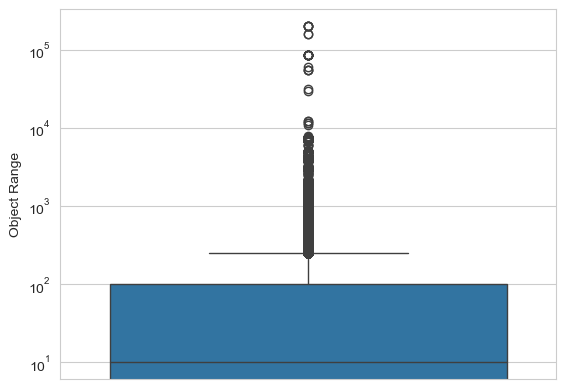

In [22]:
sns.boxplot(df_obd_oed['Object Range'])
plt.yscale('log')

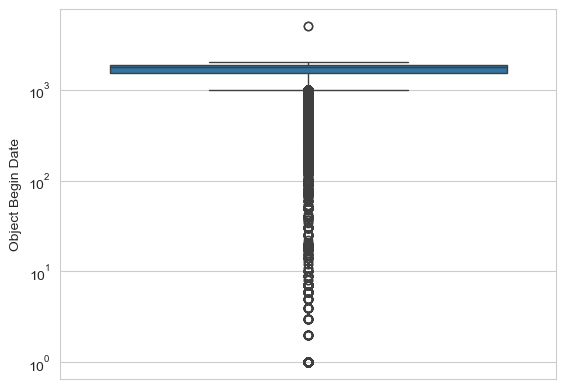

In [24]:
sns.boxplot(df_obd_oed['Object Begin Date'])
plt.yscale('log')

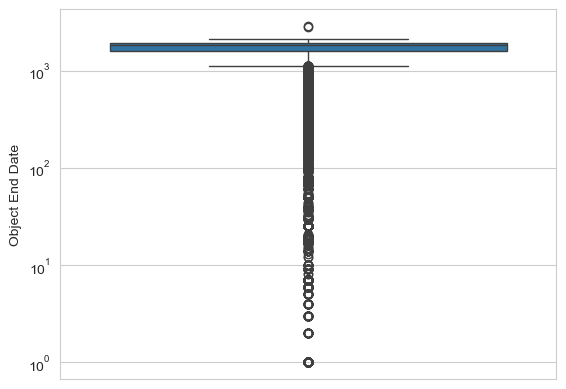

In [25]:
sns.boxplot(df_obd_oed['Object End Date'])
plt.yscale('log')

So, as we can see, there are a lot of values there. We can compute the threshold and find out those outliers. And look at them.

!!Get the number of outliers!!

In [26]:
del df_obd_oed

### Now, some analysis of the 2D data

And if there is some time, analysis of 3D data (for example female, classification number of works)

## 6. Missing Values

In [28]:
df = pd.read_csv(dataset_path)

C:\Users\nbard\AppData\Local\Temp\ipykernel_5432\1950660539.py:1: DtypeWarning: Columns (5,7,10,11,12,13,14,34,35,36,37,38,39,40,41,42,43,44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


In [32]:
df.isna().sum()

Object Number                   0
Is Highlight                    0
Is Timeline Work                0
Is Public Domain                0
Object ID                       0
Gallery Number             435415
Department                      0
AccessionYear                3862
Object Name                  2266
Title                       28803
Culture                    276766
Period                     393813
Dynasty                    461755
Reign                      473720
Portfolio                  458442
Constituent ID             202443
Artist Role                202443
Artist Prefix              202443
Artist Display Name        202443
Artist Display Bio         204533
Artist Suffix              202491
Artist Alpha Sort          202443
Artist Nationality         202443
Artist Begin Date          202443
Artist End Date            202443
Artist Gender              378474
Artist ULAN URL            257515
Artist Wikidata URL        260754
Object Date                 13431
Object Begin D

In [40]:
def analyze_missings(df, column):
    display(list(df[column].unique()))
    display(f'Number of unique: {df[column].nunique()}')
    display(f'Missing: {sum(df[column].isna())}')

In [41]:
analyze_missings(df, 'Period')

[nan,
 'Edo period (1615–1868)',
 'Qing dynasty (1644–1911)',
 'late Ming dynasty (1368–1644)',
 'Ming (1368–1644) or Qing (1644–1911) dynasty',
 'Ming dynasty (1368–1644)',
 'Ming dynasty (1368–1644) or later',
 'Ming (1368–1644) or Qing dynasty (1644–1911)',
 'Ming (1368–1644)–Qing (1644–1911) dynasty',
 'late Ming (1368–1644)–early Qing (1644–1911) dynasty',
 'late Yuan (1271–1368)–early Ming (1368–1644) dynasty',
 'Southern Song dynasty (1127–1279)',
 'Song dynasty (960–1279)',
 'Yuan dynasty (1271–1368) (?)',
 'Goryeo dynasty (918–1392)',
 'Ming dynasty (1368–1644) (?)',
 'Southern Song (1127–1279) or Yuan (1271–1368) dynasty',
 'Yuan dynasty (1271–1368)',
 'Dali kingdom (938–1253)',
 'Song dynasty (960–1279',
 'Yuan (1271–1368)–Ming (1368–1644) dynasty',
 'Meiji period (1868–1912)',
 'Ming (1368–1644) or Qing dynasty (1644–1911); or Japan, Edo period (1603–1868)',
 'Northern Song (960–1127)–Jin (1115–1234) dynasty',
 'Heian period (794–1185)',
 'Muromachi (1392–1573) or Momoyama 

'Number of unique: 1891'

'Missing: 393813'

In [42]:
analyze_missings(df, 'Culture')

[nan,
 'Mexican',
 'Guatemalan',
 'American',
 'British (American market)',
 'American or British',
 'Dutch',
 'American, Shaker',
 'British',
 'French',
 'Canadian',
 'American or French',
 'Chinese',
 'European',
 'Spanish',
 'Dutch, probably',
 'British, probably',
 'Chinese, for American market',
 'British, possibly',
 'American or Irish',
 'French, possibly',
 'American, Japanese',
 'Venezuelan',
 'British or Irish',
 'British or Flemish',
 'American, probably',
 'Bermudian, possibly',
 'Irish',
 'German',
 'Czech',
 'Chinese, for Swedish market',
 'Italian or German',
 'Bohemian',
 'British or Czech',
 'American or German',
 'European, probably',
 'Japanese',
 'Italian',
 'American, possibly',
 'British or American',
 'Italian, probably',
 'probably American',
 'Scottish',
 'French, probably',
 'European, probably British',
 'Chinese for export',
 'Japan',
 'American or Danish',
 'American or European',
 'Canadian (British)',
 'British (American Market)',
 'China',
 'Flemish',
 '

'Number of unique: 7313'

'Missing: 276766'

In [ ]:
analyze_missings(df, 'Culture')

In [43]:
analyze_missings(df, 'Country')

[nan,
 'Mexico',
 'Guatemala',
 'United States',
 'England',
 'Spain',
 'United States|England',
 'Netherlands',
 'United States|United States',
 'France',
 'Canada',
 'United States|France',
 'England|France',
 'China',
 'Italy',
 'Germany',
 'Japan',
 'Netherlands|Netherlands',
 'Czech Republic',
 'England|Ireland',
 'Ireland|United States',
 'Venezuela',
 'England|Netherlands',
 'England|Belgium',
 'France|Italy',
 'Bermuda',
 'Ireland',
 'India',
 'England|United States',
 'United States|United States|United States',
 'France|NEW ZEALAND ROTORUA WHAKAREWAREWA',
 'China|NEW ZEALAND ROTORUA WHAKAREWAREWA',
 'Germany|Italy',
 'Lisez et propagez nos Annales: "L\'Immacul‚e"',
 'France|Bernard Turner',
 'France|Harold Copping',
 'Czech Republic|England',
 'Belgium|France',
 'Belgium|England|France',
 'United States|Germany',
 'United Kingdom',
 'France|Germany',
 'Scotland',
 'Germany|Czech Republic',
 'Holland',
 'England|England',
 'United States|Denmark',
 'Finland|Denmark|United Stat

'Number of unique: 967'

'Missing: 408949'

There are a lot of unique country values. Some of them are with doubts (?). Or slashed countries, or separated with | or 'or'. Clearly we cannot just impute it by some country, etc.

In [44]:
analyze_missings(df, 'City')

[nan,
 'Philadelphia',
 'Bristol',
 'New York',
 'Lebanon',
 'Norwich',
 'East Cambridge',
 'Somerville',
 'Boston',
 'Delft',
 'Meriden',
 'Rye',
 'Oyster Bay',
 'New Lebanon',
 'London',
 'Portsmouth',
 'Boston|Philadelphia',
 'Boston|Charlestown',
 'Lititz',
 'Chicago',
 'Wakefield',
 'Portland',
 'Salem',
 'Newark',
 'New York|Paris',
 'Bennington',
 'Hartford',
 'Paris',
 'Petersburg',
 'Alexandria',
 'Concord',
 'Sandwich',
 'Pittsburgh',
 'Strasburg',
 'Middletown',
 'Baltimore',
 'Providence',
 'Preston',
 'Hartford|New York',
 'Charleston',
 'Albany',
 'Cincinnati',
 'Worcester',
 'Newburyport',
 'Barnstable|Bristol',
 'Barnstable',
 'Beverly',
 'Hancock',
 'Brooklyn',
 'Trenton',
 'Troy',
 'Cambridge',
 'Dordrecht|Amsterdam',
 'Colchester',
 'Enfield',
 'Tarentum',
 'Chelsea',
 'Zanesville',
 'Mantua|New Geneva',
 'Alloway',
 'Wistarburg',
 'Liverpool',
 'Canton',
 'Mantua',
 'Goshen',
 'New Bedford',
 'East Cambridge|Sandwich',
 'Findlay',
 'Corning',
 'Wheeling',
 'East Liv

'Number of unique: 2622'

'Missing: 452202'

Here it is even worse.

Representation os OK, clearly those are categorical nominal features. 
We can of course try more processing to make a list, or assign probability, remove duplicates, analyse lower/uppercase situations. And process data further.
But now we will not do that, we will just use imputer on lots of categorical data and will impute those values by those imputers.

In [45]:
del df

### 7. Medium feature cleaning

In [4]:
df_medium = pd.read_csv(dataset_path, usecols=['Medium'], low_memory=False)

In [50]:
analyze_missings(df_medium, 'Medium')

['Gold',
 'Silver',
 'Bronze or copper',
 'Nickel',
 'Pressed glass',
 'Mahogany, laminated',
 'Gold, amethysts, spessartites, tourmalines, fresh water pearls, quartzes, rock crystal, and enamel',
 'Oak, tulip poplar',
 'Earthenware, basalt',
 'Paper',
 'Brass, iron',
 'Brass',
 'Iron',
 'Bell metal',
 'Bell metal, possibly iron',
 'Iron, brass',
 'Brass, steel',
 'Wrought iron',
 'Brass and iron',
 'Bronze, glass, iron',
 'Earthenware',
 'Earthenware, lusterware',
 'Bronze',
 'Wood, gilt',
 'Wood',
 'Wood, marble',
 'Limestone, ceramic, and Fravrile glass',
 'Sheffield plate, earthenware, glass',
 'Bronze, gilt brass',
 'Gilt bronze',
 'Glass',
 'Oak',
 'Maple, ash',
 'Maple',
 'Hard maple, soft maple, ash',
 'Maple, oak',
 'Graphite on off-white wove paper',
 'Poplar, ash',
 'Maple, cottonwood',
 'Oak, spruce, maple',
 'Pine, ash, maple',
 'Hickory, pine',
 'Beech',
 'Ash',
 'Mahogany',
 'Walnut, white cedar, yellow pine',
 'Maple, birch',
 'Primary: mahogany.  Secondary: cherry (med

'Number of unique: 65907'

'Missing: 7215'

Our task will be classify this feature. But it has 65907 unique values. This is quite a lot. Let's see how we can reduce that number and simplify this feature

In [58]:
display_top_n_dict(unique_difference(lowercase, df_medium['Medium'].dropna()))

Number of unique values before lowercase: 65907
Number of unique values after lowercase: 64634
Difference: 1273
Ratio of values with different cases to all uniques before lowercase: 0.02
Top 5 examples:


[('gold', {'GOLD', 'Gold', 'gold'}),
 ('silver', {'SILVER', 'SIlver', 'Silver', 'silver'}),
 ('paper', {'Paper', 'paper'}),
 ('brass', {'Brass', 'brass'}),
 ('iron', {'IRON', 'Iron', 'iron'})]

As we can see, we reduced number of uniqure entities by 2 percents. Isn't much, but still better.

In [59]:
display_top_n_dict(unique_difference(whitespaces_reduction, df_medium['Medium'].dropna()))

Number of unique values before whitespaces_reduction: 65907
Number of unique values after whitespaces_reduction: 64813
Difference: 1094
Ratio of values with different cases to all uniques before whitespaces_reduction: 0.02
Top 5 examples:


[('Gold', {'Gold', 'Gold\r\n'}),
 ('Silver', {'Silver', 'Silver\r\n'}),
 ('Brass', {'Brass', 'Brass\r\n', 'Brass\r\n\r\n'}),
 ('Iron', {'Iron', 'Iron\r\n'}),
 ('Bronze', {'Bronze', 'Bronze\r\n', 'Bronze\r\n\r\n', 'Bronze\r\n\r\n\r\n'})]

In [61]:
display_top_n_dict(unique_difference(special_characters_reduction, df_medium['Medium'].dropna()))

Number of unique values before special_characters_reduction: 65907
Number of unique values after special_characters_reduction: 64033
Difference: 1874
Ratio of values with different cases to all uniques before special_characters_reduction: 0.03
Top 5 examples:


[('Gold', {'Gold', 'Gold,'}),
 ('Silver', {'Silver', 'Silver(?)', 'Silver?'}),
 ('Paper', {'Paper', 'Paper.'}),
 ('Brass', {'Brass', 'Brass.'}),
 ('Iron', {'Iron', 'Iron?'})]

Problem is, that question marks may indicate uncertainty. Which may be useful for us, which may be important information, so we will transform it without touching the question marks.

Next ideas:
using nltk remove stop words
sort words alphabetically
Looks like we will need a lot of regular expressions here to clean up this feature.


In [44]:
def split(string: str):
    if isinstance(string, str):
        return re.split(r',|and', string)
    return string

In [45]:
df_medium['Medium (List)'] = df_medium['Medium'].apply(split)

In [46]:
def standardize(l: list) -> set:
    if isinstance(l, float) and pd.isnull(l):
        return l
    standardized = set()
    for idx, el in enumerate(l):
        el = lowercase(el)
        el = special_characters_reduction(el, pattern=r'[^\w\s?]')
        el = whitespaces_reduction(el)
        if len(el) != 0:
            standardized.add(el)
    return standardized


In [47]:
df_medium['Medium (List)']

0              [Gold]
1              [Gold]
2              [Gold]
3              [Gold]
4              [Gold]
             ...     
484951    [Engraving]
484952      [Etching]
484953      [Etching]
484954            NaN
484955      [Etching]
Name: Medium (List), Length: 484956, dtype: object

In [48]:
df_medium['Medium (Standardized)'] = df_medium['Medium (List)'].apply(standardize)

In [49]:
df_medium_exploded = df_medium['Medium (Standardized)'].explode()

In [50]:
df_medium_exploded.drop_duplicates()

0                                       gold
14                                    silver
15                          bronze or copper
23                                    nickel
32                             pressed glass
                         ...                
484767               linocut printed in blue
484770                          soft varnish
484848     etching on thin white japan paper
484907    drypoint with watercolor additions
484910     etching with watercolor additions
Name: Medium (Standardized), Length: 45572, dtype: object

In [51]:
df_medium_exploded.nunique()

45571

In [52]:
df_medium_exploded.value_counts()

Medium (Standardized)
etching                                           29250
silk                                              26745
terracotta                                        23659
commercial color lithograph                       19001
engraving                                         17922
                                                  ...  
burin proof impressions                               1
before drypoint                                       1
before burnishing of the aquatint                     1
heightened with white chalk on pink laid paper        1
etching with watercolor additions                     1
Name: count, Length: 45571, dtype: int64

In [ ]:
invalid_values = ['h']

The best approach will be extracting keywords. So we will remove all the stopwords, we will remove collocations. Also we will remove the (?), because it has this keyword, so it may be silver. What we are doing here is just keyword extracting.

We see that some of the values are separated with and - so we can use this word as splitter.

In [18]:
from spellchecker import SpellChecker

In [63]:
from spellchecker import SpellChecker

spell = SpellChecker()

# find those words that may be misspelled
misspelled = spell.unknown(['something', 'is', 'hapenning', 'here'])

for word in misspelled:
    # Get the one `most likely` answer
    print(spell.correction(word))

    # Get a list of `likely` options
    print(spell.candidates(word))

happening
{'penning', 'japanning', 'happening'}


In [55]:
spell.correction('wtaermelon')

'watermelon'

In [58]:
spell.word_frequency.load_words(['wtaermelon'])

In [59]:
spell.correction('wtaermelon')

'wtaermelon'

In [64]:
spell = SpellChecker()
spell.word_frequency.add('wtaermelon', 1)

In [65]:
spell.word_frequency.add('wtaermelon', 2)

'wtaermelon'

In [66]:
from lingua import Language, LanguageDetectorBuilder

In [67]:
detector = LanguageDetectorBuilder.from_all_languages().build()

In [68]:
detector.detect_language_of('watermelon')

Language.ENGLISH

In [73]:
detector.detect_language_of('wtaermelon')

Language.BASQUE

In [74]:
detector.compute_language_confidence_values('watermelon')[:5]

[ConfidenceValue(language=Language.ENGLISH, value=0.06964716965793413),
 ConfidenceValue(language=Language.SOTHO, value=0.05910156079774358),
 ConfidenceValue(language=Language.DUTCH, value=0.05626270285948273),
 ConfidenceValue(language=Language.CATALAN, value=0.04430399072161861),
 ConfidenceValue(language=Language.AFRIKAANS, value=0.04340871579183801)]

In [75]:
detector.compute_language_confidence_values('wtaermelon')[:5]

[ConfidenceValue(language=Language.BASQUE, value=0.1054231498918336),
 ConfidenceValue(language=Language.ITALIAN, value=0.08831402399146186),
 ConfidenceValue(language=Language.WELSH, value=0.0759293267875095),
 ConfidenceValue(language=Language.CATALAN, value=0.07039671005837092),
 ConfidenceValue(language=Language.DUTCH, value=0.05568384949815356)]

Thus, we will just forget about other languages, accept some error rate, and will support only english

In [76]:
df_medium = pd.read_csv(dataset_path, usecols=['Medium'], low_memory=False)

In [6]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [105]:
nltk.download('words')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\nbard\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nbard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nbard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nbard\AppData\Roaming\nltk_data...


True

In [99]:
word_tokenize("Just some  \r\n   text?", language='english')

['Just', 'some', 'text', '?']

In [97]:
stopwords.words('english')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [107]:
filter = [word.lower() for word in
          word_tokenize("Just some     text wtaermelon   deranged melons aAaaAaAaaa?", language='english') if
          word not in stopwords.words('english')]
filter = [word for word in filter if word not in string.punctuation]
filter

['just', 'text', 'wtaermelon', 'deranged', 'melons', 'aaaaaaaaaa']

In [110]:
spell = SpellChecker()
filter_2 = [spell.correction(word) for word in filter if spell.correction(word) is not None]
filter_2

['just', 'text', 'watermelon', 'deranged', 'melons']

In [111]:
lemmatizer = WordNetLemmatizer()
filter_3 = [lemmatizer.lemmatize(word) for word in filter_2]
filter_3

['just', 'text', 'watermelon', 'deranged', 'melon']

In [117]:
lemmatizer.lemmatize('sdfasfsadfasd')

'sdfasfsadfasd'

In [3]:
df_medium = pd.read_csv(dataset_path, usecols=['Medium'], low_memory=False)

In [130]:
def extract_keywords(text: str, spellchecker: SpellChecker, lemmatizer: WordNetLemmatizer) -> set:
    if not isinstance(text, str):
        return text
    text_lower = text.lower()
    tokens = set(word_tokenize(text_lower))
    filtered = {token for token in tokens if token not in stopwords.words('english') + list(string.punctuation)}
    corrected = set()
    uncorrected = set()
    for token in filtered:
        correction: str | None = spellchecker.correction(token)
        if correction is None:
            uncorrected.add(token)
        else:
            corrected.add(correction)

    lemmatized = {lemmatizer.lemmatize(token) for token in corrected}
    return lemmatized | uncorrected

In [122]:
list(string.punctuation)

['!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '{',
 '|',
 '}',
 '~']

In [131]:
df_medium['Keywords'] = df_medium['Medium'].apply(extract_keywords, spellchecker=SpellChecker(),
                                                  lemmatizer=WordNetLemmatizer())
# too long computationally. Spellchecers and lemmatizers are too long.

KeyboardInterrupt: 

In [33]:
re.split(r'\\', 'sd\\f')

['sd', 'f']

['sdf']

In [50]:
def tokenize(text: str) -> set:
    if not isinstance(text, str):
        return text
    text_lower = text.lower()
    tokens = word_tokenize(text_lower)
    cleaned_tokens = set()
    for token in tokens:
        subtokens = re.split(r'\\|-', token)
        for subtoken in subtokens:
            cleaned = re.sub(r'[^\w]', '', subtoken)
            if len(cleaned) > 0:
                cleaned_tokens.add(cleaned)
    return cleaned_tokens

In [51]:
df_medium['Medium (Tokenized)'] = df_medium['Medium'].apply(tokenize)

In [52]:
df_medium_exploded = df_medium['Medium (Tokenized)'].explode()

In [138]:
df_medium_exploded_filtered = df_medium['Medium (Tokenized)'].filter(lambda x: len(x) != 0)

0              gold
1              gold
2              gold
3              gold
4              gold
            ...    
484951    engraving
484952      etching
484953      etching
484954          NaN
484955      etching
Name: Medium (Tokenized), Length: 1733900, dtype: object

In [146]:
df_test = pd.DataFrame({'A': [[1, 2, 3], [4, 5, 6], [7, 8, 9]]})
df_test_exploded = df_test.explode(column='A')
df_test_exploded


,A
0,1
0,2
0,3
1,4
1,5
1,6
2,7
2,8
2,9


In [165]:
df_test_exploded_filtered = df_test_exploded['A'][~df_test_exploded['A'].isin([4, 6, 7, 8, 9])]
df_test_exploded_filtered

0    1
0    2
0    3
1    5
Name: A, dtype: object

In [169]:
df_test_exploded_filtered.groupby(df_test_exploded_filtered.index).agg(list).reindex(df_test.index)

0    [1, 2, 3]
1          [5]
2          NaN
Name: A, dtype: object

In [53]:
medium_uniques = df_medium_exploded.dropna().unique()

In [54]:
medium_uniques


array(['gold', 'silver', 'or', ..., 'mou', 'please', 'taken'],
      dtype=object)

In [55]:
len(medium_uniques)

8984

In [12]:
mapping = {}

In [194]:
df_test = pd.DataFrame({'A': [{'a', 'b', 'c'}, {'a', 'b'}]})
df_test

,A
0,"{a, c, b}"
1,"{a, b}"


In [197]:
one_hot = {'a', 'c'}
for feature in one_hot:
    df_test[feature] = df_test['A'].apply(lambda x: 1 if isinstance(x, set) and feature in x else 0)

In [198]:
df_test

,A,a,c
0,"{a, c, b}",1,1
1,"{a, b}",1,0


In [202]:
len(medium_uniques)

10487

In [205]:
s = {1, 2, 3}
for el in tqdm(s):
    print("Hi")

100%|██████████| 3/3 [00:00<?, ?it/s]

Hi
Hi
Hi


In [13]:
from tqdm import tqdm

In [56]:
words = [token for token in medium_uniques if
         token not in stopwords.words('english') and token not in list(string.punctuation)]

In [57]:
len(medium_uniques)

8984

In [58]:
len(words)

8885

In [20]:
from multiprocessing import Pool

In [68]:
mappings = dict()
spell = SpellChecker()
lemmatizer = WordNetLemmatizer()

for token in tqdm(words):
    spellcheked = spell.correction(token)
    if spellcheked is None:
        mapping[token] = token
    else:
        mapping[token] = lemmatizer.lemmatize(spellcheked)


100%|██████████| 8885/8885 [16:00<00:00,  9.25it/s]  


16 minutes... Too much

In [75]:
mapping

{'gold': 'gold',
 'silver': 'silver',
 'bronze': 'bronze',
 'copper': 'copper',
 'nickel': 'nickel',
 'pressed': 'pressed',
 'glass': 'glass',
 'mahogany': 'mahogany',
 'laminated': 'laminated',
 'spessartites': 'spessartite',
 'pearls': 'pearl',
 'fresh': 'fresh',
 'enamel': 'enamel',
 'amethysts': 'amethyst',
 'crystal': 'crystal',
 'water': 'water',
 'rock': 'rock',
 'tourmalines': 'tourmaline',
 'quartzes': "quartz's",
 'tulip': 'tulip',
 'oak': 'oak',
 'poplar': 'poplar',
 'basalt': 'basalt',
 'earthenware': 'earthenware',
 'paper': 'paper',
 'iron': 'iron',
 'brass': 'brass',
 'metal': 'metal',
 'bell': 'bell',
 'possibly': 'possibly',
 'steel': 'steel',
 'wrought': 'wrought',
 'lusterware': 'lusterware',
 'gilt': 'gilt',
 'wood': 'wood',
 'marble': 'marble',
 'fravrile': 'fragile',
 'ceramic': 'ceramic',
 'limestone': 'limestone',
 'plate': 'plate',
 'sheffield': 'sheffield',
 'maple': 'maple',
 'ash': 'ash',
 'hard': 'hard',
 'soft': 'soft',
 'graphite': 'graphite',
 'wove': 'w

In [79]:
len(mapping)

8885

In [80]:
len(set(mapping.values()))

7063

By spellcheck and lemmatization we again reduced number of unique tokens to 7063. This is quite a result. Now we need to take the most frequent values.

In [76]:
import pickle

with open('spellcheck_lemmatized.pickle', 'wb') as f:
    pickle.dump(mapping, f)

In [77]:
with open('spellcheck_lemmatized.pickle', 'rb') as f:
    test = pickle.load(f)

In [78]:
test

{'gold': 'gold',
 'silver': 'silver',
 'bronze': 'bronze',
 'copper': 'copper',
 'nickel': 'nickel',
 'pressed': 'pressed',
 'glass': 'glass',
 'mahogany': 'mahogany',
 'laminated': 'laminated',
 'spessartites': 'spessartite',
 'pearls': 'pearl',
 'fresh': 'fresh',
 'enamel': 'enamel',
 'amethysts': 'amethyst',
 'crystal': 'crystal',
 'water': 'water',
 'rock': 'rock',
 'tourmalines': 'tourmaline',
 'quartzes': "quartz's",
 'tulip': 'tulip',
 'oak': 'oak',
 'poplar': 'poplar',
 'basalt': 'basalt',
 'earthenware': 'earthenware',
 'paper': 'paper',
 'iron': 'iron',
 'brass': 'brass',
 'metal': 'metal',
 'bell': 'bell',
 'possibly': 'possibly',
 'steel': 'steel',
 'wrought': 'wrought',
 'lusterware': 'lusterware',
 'gilt': 'gilt',
 'wood': 'wood',
 'marble': 'marble',
 'fravrile': 'fragile',
 'ceramic': 'ceramic',
 'limestone': 'limestone',
 'plate': 'plate',
 'sheffield': 'sheffield',
 'maple': 'maple',
 'ash': 'ash',
 'hard': 'hard',
 'soft': 'soft',
 'graphite': 'graphite',
 'wove': 'w

In [59]:
unknown = spell.unknown(words)
unknown


{'shiwan',
 'ceylon',
 'francis',
 'slazed',
 'sforzesca',
 'lines803234',
 'sarasa',
 'sashiko',
 'pastinachus',
 'ffff',
 'sumak',
 'ziziphus',
 'stephen',
 'sempervirens',
 'cuban',
 '18kt',
 'shimoshirakawa',
 'yamimakie',
 'edgeing',
 'sur',
 'rockman',
 'differentialy',
 'yoko',
 'photosilkscreens',
 'ahir',
 'basra',
 'abete',
 'bromoil',
 'pencilink',
 'tapa',
 'lamé',
 'parinarium',
 'zhun',
 'pseudomorph',
 'mura',
 'pre',
 'furuta',
 'yamabushi',
 'bleute',
 'silhouettecut',
 'ozotype',
 'gaouche',
 'chromoxylograph',
 'kan',
 'cedrus',
 'stainings',
 'rosewod',
 'ak',
 'tetraptych',
 'kyo',
 'wedgwood',
 'cas',
 'graphiteand',
 'mimeographblue',
 'kurotani',
 'aberinberin',
 'lettersheet',
 'zōgan',
 'eiraku',
 'flashe',
 'undegummed',
 'nambam',
 'orangish',
 'mikawachi',
 'sze',
 'fajian',
 'promontorio',
 'campan',
 'rootwood',
 'abc',
 'yashichida',
 'manjū',
 'adam',
 'allowy',
 'di',
 'abrus',
 'sultanabad',
 'aubri',
 'makassar',
 'aquantint',
 'leiure',
 'belleek',


In [67]:
len(unknown)

3225

'talk'

In [221]:
'good' in spell.word_frequency.words()

True

In [69]:
spell.candidates('italy')

{'bialy',
 'coaly',
 'fatly',
 'fitly',
 'icily',
 'idly',
 'imply',
 'inlay',
 'inly',
 "it'll",
 'italic',
 'itchy',
 'litany',
 'mealy',
 'paly',
 'patly',
 'scaly',
 'stably',
 'stagy',
 'stale',
 'stalk',
 'stalky',
 'stall',
 'stay',
 'tala',
 'talc',
 'tale',
 'tali',
 'talk',
 'talky',
 'tall',
 'tally',
 'vital',
 'vitally',
 'vitals'}

In [60]:
spell.candidates('italy')

{'bialy',
 'coaly',
 'fatly',
 'fitly',
 'icily',
 'idly',
 'imply',
 'inlay',
 'inly',
 "it'll",
 'italic',
 'itchy',
 'litany',
 'mealy',
 'paly',
 'patly',
 'scaly',
 'stably',
 'stagy',
 'stale',
 'stalk',
 'stalky',
 'stall',
 'stay',
 'tala',
 'talc',
 'tale',
 'tali',
 'talk',
 'talky',
 'tall',
 'tally',
 'vital',
 'vitally',
 'vitals'}

In [84]:
df_medium_mapped = df_medium_exploded.apply(lambda x: mapping[x] if isinstance(x, str) and x in mapping else np.NaN)

In [88]:
vc = df_medium_mapped.value_counts()
vc

Medium (Tokenized)
etching        43438
lithograph     39347
color          36697
silver         36406
print          34449
               ...  
photoetched        1
doggie             1
alfresco           1
tompion            1
taken              1
Name: count, Length: 7063, dtype: int64

Color doesn't make any sense here - all items has some color, so we can remove it

In [92]:
to_remove = ['color', 'two', 'second', 'third']

In [94]:
for removed in to_remove:
    if removed in mapping:
        del mapping[removed]

In [95]:
df_medium_mapped = df_medium_exploded.apply(lambda x: mapping[x] if isinstance(x, str) and x in mapping else np.NaN)
df_medium_mapped.value_counts()

Medium (Tokenized)
etching       43438
lithograph    39347
silver        36406
print         34449
silk          34027
              ...  
enthroned         1
seraglio          1
empty             1
oriented          1
taken             1
Name: count, Length: 7063, dtype: int64

In [98]:
for_one_hot = set(df_medium_mapped.value_counts().nlargest(50).index)
for_one_hot

{'albumen',
 'black',
 'bronze',
 'brown',
 'colored',
 'commercial',
 'copper',
 'cotton',
 'earthenware',
 'engraving',
 'etching',
 'faïence',
 'film',
 'gelatin',
 'gilt',
 'glass',
 'glazed',
 'gold',
 'gouache',
 'graphite',
 'hand',
 'illustration',
 'ink',
 'iron',
 'leather',
 'linen',
 'lithograph',
 'metal',
 'negative',
 'paint',
 'painted',
 'paper',
 'pen',
 'photograph',
 'photolithography',
 'porcelain',
 'print',
 'printed',
 'silk',
 'silver',
 'state',
 'steel',
 'terracotta',
 'thread',
 'wash',
 'watercolor',
 'white',
 'wood',
 'woodcut',
 'wool'}

In [ ]:
df_medium['Cleaned'] = df_medium['Medium (Tokenized)']

### 8. Dimensions

In [128]:
df_dimensions = pd.read_csv(dataset_path, usecols=['Dimensions'], low_memory=False)

In [65]:
df_dimensions['Dimensions'].unique()

array(['Dimensions unavailable', 'Diam. 11/16 in. (1.7 cm)',
       'Diam. 1/2 in. (1.3 cm)', ...,
       'Plate: 8 3/4 × 5 7/8 in. (22.2 × 15 cm)\r\nSheet: 12 3/16 × 8 3/8 in. (31 × 21.2 cm)',
       '2 pages, 30 unnumbered leaves of plates (some color and folded) : illustrations (some color) ; Height: 11 7/16 in. (29 cm)',
       'Image: 6 5/8 × 11 3/4 in. (16.9 × 29.9 cm)\r\nPlate: 8 15/16 × 13 5/8 in. (22.7 × 34.6 cm)\r\nSheet: 10 13/16 × 15 9/16 in. (27.4 × 39.5 cm)'],
      dtype=object)